In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clientes = pd.read_csv('/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/clientes.csv')
df_churn = pd.read_csv('data/raw/churn_target.csv')


In [3]:
print(df_clientes.shape)
print(df_churn.shape)

df_clientes.info()
df_churn.info()

df_clientes.head()
df_churn.head()

(10150, 14)
(321987, 3)
<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10150 non-null  str    
 1   zona_id           10150 non-null  str    
 2   region            10150 non-null  str    
 3   tipo_zona         10150 non-null  str    
 4   poblacion_zona    10150 non-null  int64  
 5   edad              9845 non-null   float64
 6   sexo              10105 non-null  str    
 7   estado_civil      10071 non-null  str    
 8   num_lineas        10150 non-null  int64  
 9   tipo_plan         10150 non-null  str    
 10  tipo_dispositivo  10150 non-null  str    
 11  ingreso_estimado  9846 non-null   float64
 12  antiguedad_meses  9845 non-null   float64
 13  descuento_activo  10150 non-null  int64  
dtypes: float64(3), int64(3), str(8)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 321987 entries, 0 to 321986
D

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [4]:
df_clientes = df_clientes.drop_duplicates(subset="cliente_id")

In [5]:
churn_cliente = df_churn.groupby("cliente_id")["churn"].max().reset_index()

In [6]:
df = df_clientes.merge(churn_cliente, on="cliente_id", how="left")

In [7]:
df.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
churn                 0
dtype: int64

In [25]:
df["antiguedad_meses"] = df["antiguedad_meses"].fillna(df["antiguedad_meses"].mean())

In [8]:
df["edad"] = df["edad"].fillna(df["edad"].mean())
df["ingreso_estimado"] = df["ingreso_estimado"].fillna(df["ingreso_estimado"].mean())
df["antiguedad_meses"] = df["antiguedad_meses"].fillna(df["antiguedad_meses"].mean())

In [9]:
df["sexo"] = df["sexo"].fillna(df["sexo"].mode()[0])
df["estado_civil"] = df["estado_civil"].fillna(df["estado_civil"].mode()[0])

In [10]:
df.loc[df["antiguedad_meses"] < 0, "antiguedad_meses"] = None

In [11]:
df["churn"].value_counts(normalize=True)

churn
0    0.8
1    0.2
Name: proportion, dtype: float64

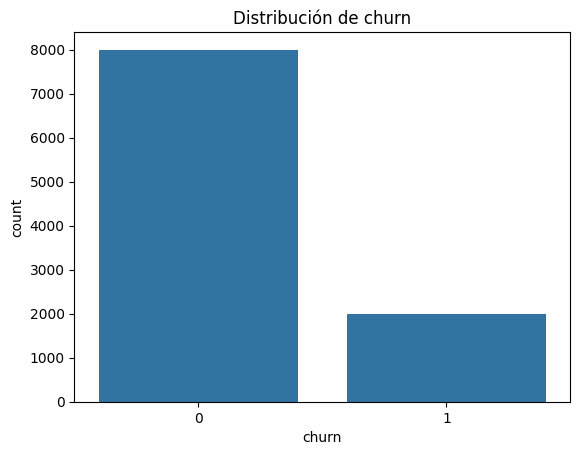

In [12]:
sns.countplot(data=df, x="churn")
plt.title("Distribución de churn")
plt.show()

In [13]:
df.groupby("churn")["antiguedad_meses"].mean()

churn
0    34.776221
1    28.573139
Name: antiguedad_meses, dtype: float64

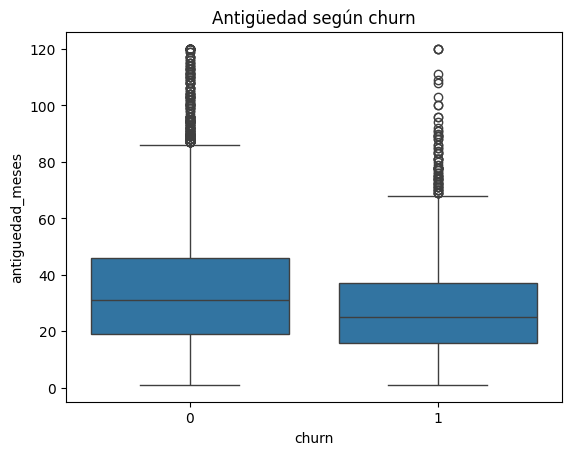

In [14]:
sns.boxplot(data=df, x="churn", y="antiguedad_meses")
plt.title("Antigüedad según churn")
plt.show()

Los clientes con menor antigüedad presentan mayor churn.

In [15]:
df.groupby("tipo_plan")["churn"].mean().sort_values(ascending=False)

tipo_plan
Prepago     0.262313
Contrato    0.214349
Premium     0.160608
Name: churn, dtype: float64

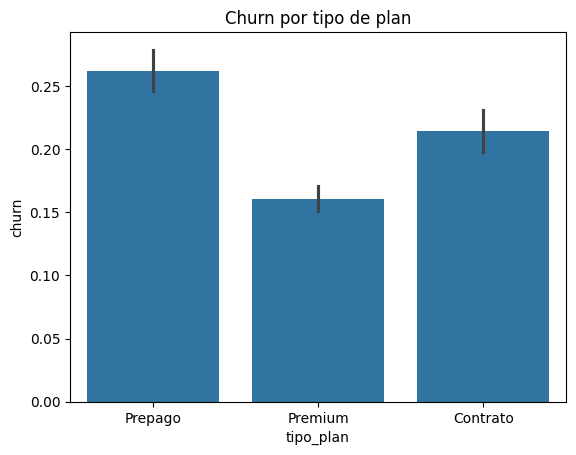

In [16]:
sns.barplot(data=df, x="tipo_plan", y="churn")
plt.title("Churn por tipo de plan")
plt.show()

Los clientes con descuento activo tienen menor churn.

In [17]:
df.groupby("tipo_zona")["churn"].mean().sort_values(ascending=False)

tipo_zona
rural             0.329759
suburbana         0.213522
urbana_premium    0.144705
Name: churn, dtype: float64

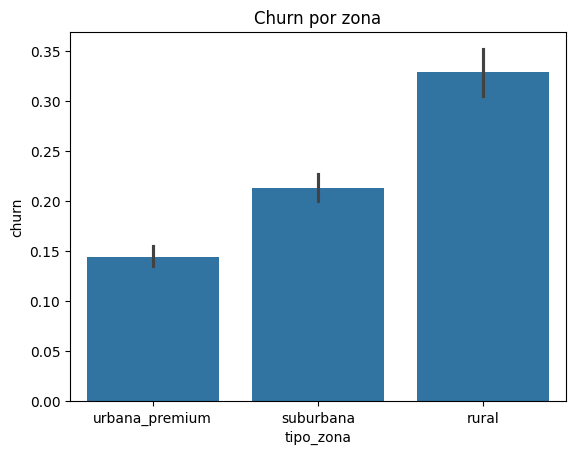

In [18]:
sns.barplot(data=df, x="tipo_zona", y="churn")
plt.title("Churn por zona")
plt.show()

In [ ]:
Las zonas rurales presentan mayor churn.

In [20]:
df.groupby("churn")["ingreso_estimado"].mean()

churn
0    3579.574369
1    3065.636028
Name: ingreso_estimado, dtype: float64

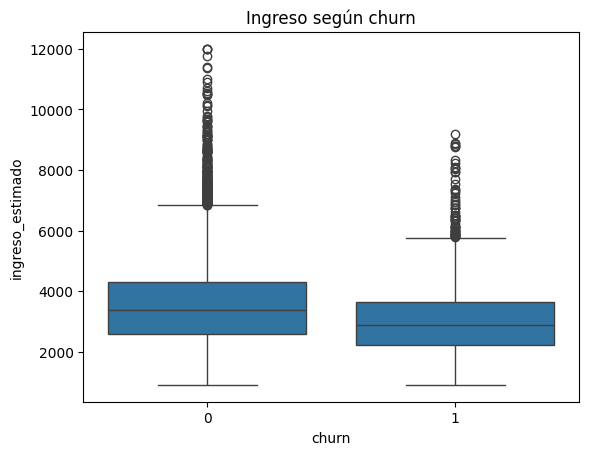

In [21]:
sns.boxplot(data=df, x="churn", y="ingreso_estimado")
plt.title("Ingreso según churn")
plt.show()

El ingreso muestra diferencias entre clientes con y sin churn.

In [22]:
df.groupby("region")["churn"].mean()
df.groupby("num_lineas")["churn"].mean()
df.groupby("edad")["churn"].mean()

edad
18.0    0.170732
19.0    0.131868
20.0    0.074468
21.0    0.210938
22.0    0.166667
          ...   
76.0    0.500000
77.0    0.666667
78.0    0.250000
79.0    0.000000
80.0    0.000000
Name: churn, Length: 64, dtype: float64

El análisis muestra que el churn no se distribuye de manera uniforme entre los clientes. Se observa que los clientes con menor antigüedad, aquellos con planes prepago, los que residen en zonas rurales y los que no tienen descuentos activos presentan una mayor probabilidad de abandono. Estos resultados permiten identificar segmentos de alto riesgo sobre los que se deberían enfocar estrategias de retención.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10000 non-null  str    
 1   zona_id           10000 non-null  str    
 2   region            10000 non-null  str    
 3   tipo_zona         10000 non-null  str    
 4   poblacion_zona    10000 non-null  int64  
 5   edad              10000 non-null  float64
 6   sexo              10000 non-null  str    
 7   estado_civil      10000 non-null  str    
 8   num_lineas        10000 non-null  int64  
 9   tipo_plan         10000 non-null  str    
 10  tipo_dispositivo  10000 non-null  str    
 11  ingreso_estimado  10000 non-null  float64
 12  antiguedad_meses  10000 non-null  float64
 13  descuento_activo  10000 non-null  int64  
 14  churn             10000 non-null  int64  
dtypes: float64(3), int64(4), str(8)
memory usage: 1.1 MB
